# Re-process paper data

# Data fitting test for no shuttling 9-ion rabi oscillation with 300us delay

In [1]:
from qutip import *
from scipy.optimize import curve_fit
import math
import cmath
import timeit
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from time import time
from pynverse import inversefunc
from mpl_toolkits.axisartist.axislines import SubplotZero
import matplotlib
import h5py as h5
from scipy.special import laguerre
from scipy.integrate import dblquad, quad
import scipy

# Update matplotlib settings for consistent appearance in plots
matplotlib.rcParams.update(
    {"font.family": "STIXGeneral",
     "xtick.labelsize": 12,
     "xtick.direction": "in",
     "xtick.major.pad": 3,
     "xtick.top": True,
     "ytick.labelsize": 12,
     "ytick.direction": "in",
     "ytick.right": True,
     "axes.labelsize": 12,
     "axes.labelpad": 3,
     "axes.grid": True
    }
)

# File loading function
def file_loading(data_path, date, index, number, x='rabi_t', y='pmt_counts_avg_thresholded', exp='RabiTimeScan'):
    # Construct full file path
    file_path = data_path + date + index + f"/0000{number}-" + exp + ".h5"
    # For debugging or direct file usage, you can hardcode file_path if needed.
    # file_path = data_path  # If you directly used a fixed path
    
    with h5.File(file_path, "r") as file:
        datasets_keys = list(file['datasets'].keys())
        print("Datasets available:", datasets_keys)
        x_data = file['datasets'][x][:]
        y_data = file['datasets'][y][:]
        
    return x_data, y_data, np.linspace(np.min(x_data), np.max(x_data), 300)


###########################################
# Load and preprocess the data
###########################################

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30462

# data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
# date = "2024-10-27/"
# number = 30462
# file_path = data_path + date + f"19/0000{number}-RabiTimeScan.h5"

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [9]
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

###########################################
# Define the model and fit parameters
###########################################

n_ions = 9
N = 300

def pe_model_optimized(time, rabi_0_fit, nbar_fit, nalpha_fit, N=300):
    ndisplace_fit = complex(0, np.sqrt(nalpha_fit))
    intensity_distribution = np.array([0.96912696, 0.9844114, 0.99344862, 0.99840835, 1., 0.99840835, 0.99344862, 0.9844114, 0.96912696])
    pe_fit = np.zeros_like(time)
    diagonal_elements_all = np.zeros(N)
    for k in range(len(intensity_distribution)):
        if(k < 4):
            eta = 0.23/np.sqrt(n_ions)    # LD parameter
            eta_squared_laguerre_values = [laguerre(i)(eta**2) for i in range(N)]
            inputstate_fit = displace(N, ndisplace_fit) * thermal_dm(N, nbar_fit) * displace(N, ndisplace_fit).dag()
            diagonal_elements = np.abs(inputstate_fit.full().diagonal())
            diagonal_elements_all += 2 * diagonal_elements
            for i in range(N):
                pe_fit += 2 * diagonal_elements[i] * np.sin(intensity_distribution[k] * rabi_0_fit * eta_squared_laguerre_values[i] * time)**2
        elif(k == 4):
            eta = 0.23/np.sqrt(n_ions)    # LD parameter
            eta_squared_laguerre_values = [laguerre(i)(eta**2) for i in range(N)]
            inputstate_fit = displace(N, ndisplace_fit) * thermal_dm(N, nbar_fit) * displace(N, ndisplace_fit).dag()
            diagonal_elements = np.abs(inputstate_fit.full().diagonal())
            diagonal_elements_all += diagonal_elements
            for i in range(N):
                pe_fit += diagonal_elements[i] * np.sin(intensity_distribution[k] * rabi_0_fit * eta_squared_laguerre_values[i] * time)**2
    return pe_fit / 9, diagonal_elements_all / 9

def pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=300):
    ndisplace_fit = complex(0, np.sqrt(nalpha_fit))
    intensity_distribution = np.array([0.96912696, 0.9844114, 0.99344862, 0.99840835, 1., 0.99840835, 0.99344862, 0.9844114, 0.96912696])
    pe_fit = 0
    diagonal_elements_all = np.zeros(N)
    for k in range(len(intensity_distribution)):
        if(k < 4):
            eta = 0.23/np.sqrt(n_ions)    # LD parameter
            eta_squared_laguerre_values = [laguerre(i)(eta**2) for i in range(N)]
            inputstate_fit = displace(N, ndisplace_fit) * thermal_dm(N, nbar_fit) * displace(N, ndisplace_fit).dag()
            diagonal_elements = np.abs(inputstate_fit.full().diagonal())
            diagonal_elements_all += 2 * diagonal_elements
            for i in range(N):
                pe_fit += 2 * diagonal_elements[i] * np.sin(intensity_distribution[k] * rabi_0_fit * eta_squared_laguerre_values[i] * time)**2
        elif(k == 4):
            eta = 0.23/np.sqrt(n_ions)    # LD parameter
            eta_squared_laguerre_values = [laguerre(i)(eta**2) for i in range(N)]
            inputstate_fit = displace(N, ndisplace_fit) * thermal_dm(N, nbar_fit) * displace(N, ndisplace_fit).dag()
            diagonal_elements = np.abs(inputstate_fit.full().diagonal())
            diagonal_elements_all += diagonal_elements
            for i in range(N):
                pe_fit += diagonal_elements[i] * np.sin(intensity_distribution[k] * rabi_0_fit * eta_squared_laguerre_values[i] * time)**2
    return pe_fit / 9

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit, N=300):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N)

# Initial guesses
# initial_guess = [0.1, 30, 0.0]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.05, 0, 0), (0.15, 10, 300))
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)


Fitted parameters:
rabi =  0.10041706038983479
nbar =  8.750919672001146
nalpha =  14.914835773079174


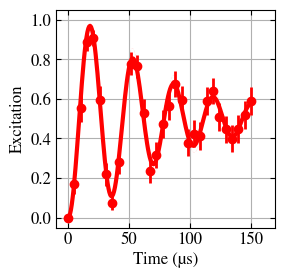

In [2]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Data fitting test for no shuttling 9-ion rabi oscillation with 250us delay

In [6]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30406

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [9]
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.15

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.05, 0, 0), (0.15, 10, 300))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters:
rabi =  0.11346637860070893
nbar =  6.985951514534256
nalpha =  14.77022429033909


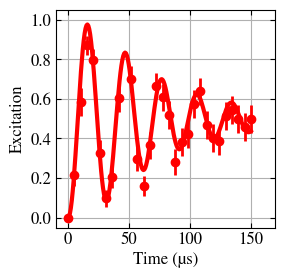

In [7]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
# nbars = [nbar - 3, nbar, nbar + 3]
nbars = [nbar]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')

# plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
# plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)

plt.plot(time, results[0], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')

# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Data fitting test for no shuttling 9-ion rabi oscillation with 200us delay

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)


Fitted parameters:
rabi =  0.11073578838572208
nbar =  9.999999999999734
nalpha =  6.55557008486283


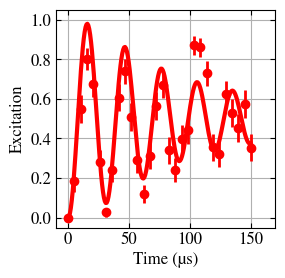

In [9]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30400

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.15

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.05, 0, 0), (0.15, 10, 300))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
# nbars = [nbar - 3, nbar, nbar + 3]
nbars = [nbar]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')

# plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
# plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)

plt.plot(time, results[0], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')

# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Data fitting test for no shuttling 9-ion rabi oscillation with 170us delay

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)


Fitted parameters:
rabi =  0.10232534178660563
nbar =  7.488800580826234
nalpha =  13.555016442269332


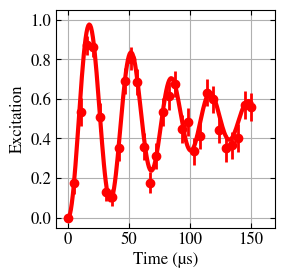

In [11]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30388

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.15

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.05, 0, 0), (0.15, 10, 300))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
# nbars = [nbar - 3, nbar, nbar + 3]
nbars = [nbar]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=300)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')

# plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
# plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)

plt.plot(time, results[0], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')

# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Data fitting test for no shuttling 9-ion rabi oscillation with 150us delay

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)


Fitted parameters:
rabi =  0.11357538018378775
nbar =  9.999999999916092
nalpha =  6.509269383825426


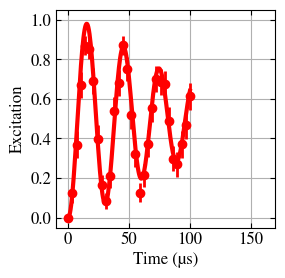

In [12]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30376

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.15

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.05, 0, 0), (0.15, 10, 300))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
# nbars = [nbar - 3, nbar, nbar + 3]
nbars = [nbar]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=300)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')

# plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
# plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)

plt.plot(time, results[0], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')

# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Data fitting test for no shuttling 9-ion rabi oscillation with 0us delay

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)


Fitted parameters:
rabi =  0.11331380344765626
nbar =  2.7435118951957973
nalpha =  16.936257266828523


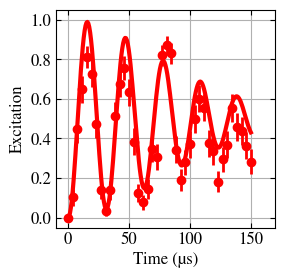

In [13]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30344

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.15

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.05, 0, 0), (0.15, 10, 300))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
# nbars = [nbar - 3, nbar, nbar + 3]
nbars = [nbar]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=300)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')

# plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
# plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)

plt.plot(time, results[0], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')

# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Data fitting test for no shuttling 9-ion rabi oscillation with 1000us delay

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)


Fitted parameters:
rabi =  0.1135647672767642
nbar =  9.999999999999988
nalpha =  22.086964624735696


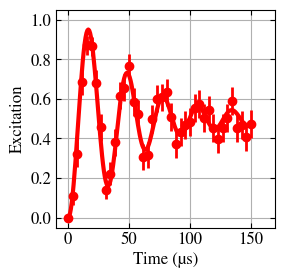

In [14]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30342

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.15

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.05, 0, 0), (0.15, 10, 300))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
# nbars = [nbar - 3, nbar, nbar + 3]
nbars = [nbar]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=300)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')

# plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
# plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)

plt.plot(time, results[0], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')

# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 6.00 kHz shuttling speed

In [28]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30524

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [9]
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.25

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.05, 0, 40), (0.11, 15, 130))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)


Fitted parameters:
rabi =  0.05476172602016696
nbar =  14.366200041591325
nalpha =  49.39390710153437


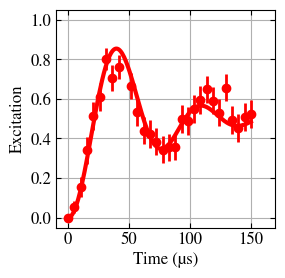

In [29]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
# nbars = [nbar - 3, nbar, nbar + 3]
nbars = [nbar]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')

# plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
# plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)

plt.plot(time, results[0], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')

# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 6.02 kHz shuttling speed

In [31]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30534

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [-12]  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.4

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.05, 0, 50), (0.15, 20, 500))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters:
rabi =  0.1140311609616315
nbar =  5.289990743326477
nalpha =  165.1129566298787


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)


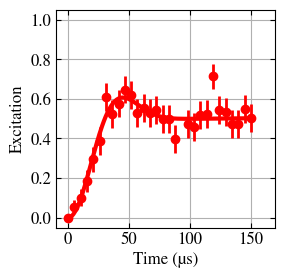

In [33]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
# nbars = [nbar - 3, nbar, nbar + 3]
nbars = [nbar]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')

# plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
# plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)

plt.plot(time, results[0], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')

# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 6.01 kHz shuttling speed

In [11]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30542

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [9]  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.25

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 500))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters:
rabi =  0.0517342859681359
nbar =  22.999999999999996
nalpha =  42.126115596758176


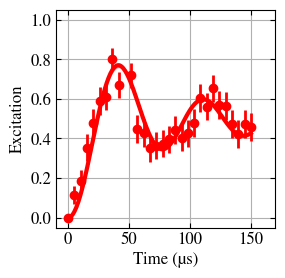

In [43]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 6.20 kHz shuttling speed

In [44]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30522

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [9]  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 100, 500))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)


Fitted parameters:
rabi =  0.14838715690606424
nbar =  1.1425393293148469e-11
nalpha =  193.6168012588662


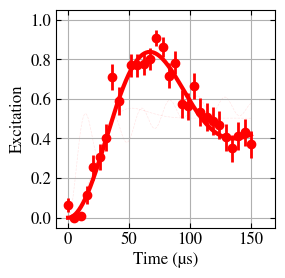

In [45]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 6.38 kHz shuttling speed

In [16]:
# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=500)

In [18]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30516

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [9]  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.3

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 500))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters:
rabi =  0.14999999999963867
nbar =  0.3907539830480749
nalpha =  287.39378826434734


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogon

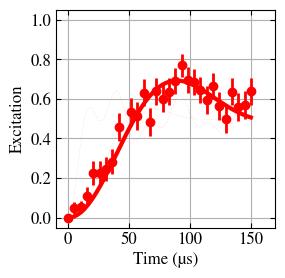

In [20]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=500)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 5.90 kHz shuttling speed

In [21]:
# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=500)

In [22]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30528

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [9]  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.3

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 500))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogon

Fitted parameters:
rabi =  0.0499786391608075
nbar =  22.99999999957004
nalpha =  371.7625949737293


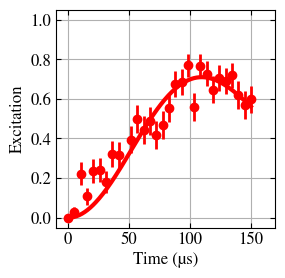

In [23]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=500)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 4.80 kHz shuttling speed

In [51]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30574

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.3

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 100, 500))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogon

Fitted parameters:
rabi =  0.10781724214375786
nbar =  11.531506862418958
nalpha =  378.8441806071766


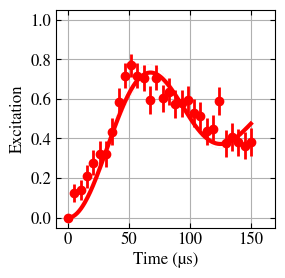

In [52]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 4.763 kHz shuttling speed

In [53]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30424

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [9]  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.3

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 100, 500))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogon

Fitted parameters:
rabi =  0.04941145051787442
nbar =  22.445130356768892
nalpha =  45.61169328495941


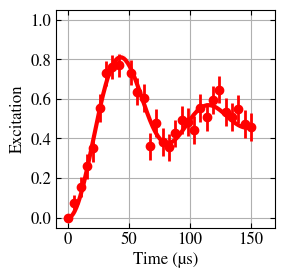

In [54]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 4.762 kHz shuttling speed

In [5]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30412

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [-7, -8, -9]  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.3

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 500))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)


Fitted parameters:
rabi =  0.04640884731878425
nbar =  22.99999999999971
nalpha =  36.838562612507836


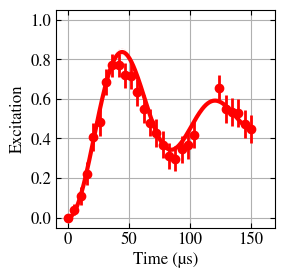

In [6]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 4.759 kHz shuttling speed

In [57]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30444

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.3

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 100, 500))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogon

Fitted parameters:
rabi =  0.050679007524362614
nbar =  24.929860356520162
nalpha =  74.57247816062034


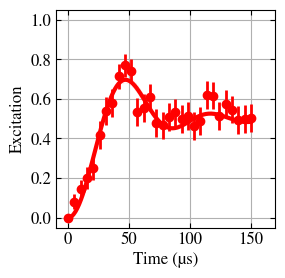

In [58]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 4.5 kHz shuttling speed

In [7]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30576

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.3

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 500))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)


Fitted parameters:
rabi =  0.034894431096967445
nbar =  22.999999999999996
nalpha =  191.30560341168453


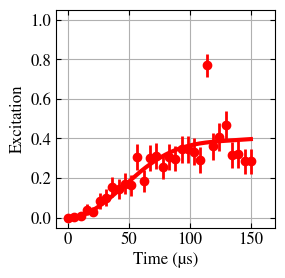

In [8]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 3.846 kHz shuttling speed

In [61]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30466

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 100, 500))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogon

Fitted parameters:
rabi =  0.13872963985871087
nbar =  8.665911672497971
nalpha =  384.7639818093538


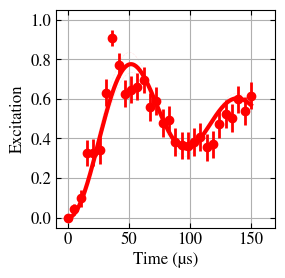

In [62]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 5.0 kHz shuttling speed

In [9]:
n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30408

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 100, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)


Fitted parameters:
rabi =  0.07410189646187604
nbar =  0.22405943917499913
nalpha =  455.8798390444473


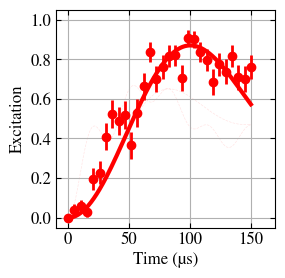

In [64]:
# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Shuttling data with 8.25 kHz shuttling speed

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogon

Fitted parameters:
rabi =  0.09660412743223261
nbar =  3.6365309152281096e-10
nalpha =  770.6825546875536


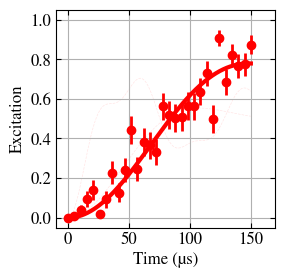

In [24]:
# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=500)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30382

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=500)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogon

Fitted parameters:
rabi =  0.1133642642984403
nbar =  4.3848724553215365e-10
nalpha =  736.6950716708415


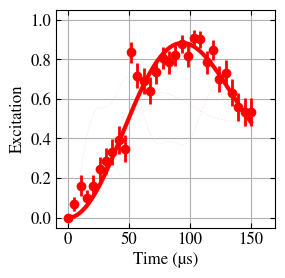

In [25]:
'''Shuttling data with 6.666 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30390

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in true_divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogon

Fitted parameters:
rabi =  0.11176692586535064
nbar =  1.6903724683167576e-10
nalpha =  305.7229150725927


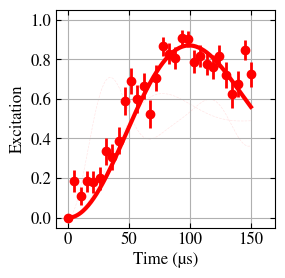

In [ ]:
'''Shuttling data with 6.566 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30394

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters:
rabi =  0.14999999999999997
nbar =  0.4004746825280375
nalpha =  733.7204853775961


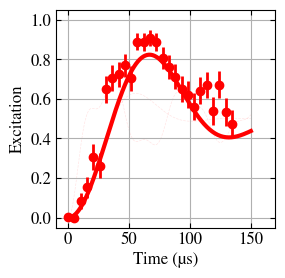

In [31]:
'''Shuttling data with 6.493 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30416

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [-1, -2, -3]  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513: RuntimeWarning: overflow encountered in multiply
  - (n + alpha)*cephes.eval_genlaguerre(n-1, alpha, x))/x
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:194: RuntimeWarning: invalid value encountered in divide
  dy /= np.abs(dy).max()


Fitted parameters:
rabi =  0.1499999999999857
nbar =  0.4173190995653656
nalpha =  756.7204121584281


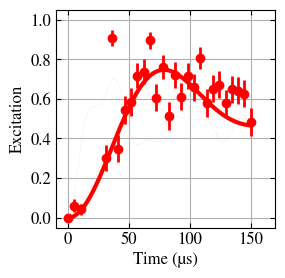

In [2]:
'''Shuttling data with 6.451 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30468

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [3, 4, 5]  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.08309417733708804
nbar =  22.999999999999996
nalpha =  716.9477855870338


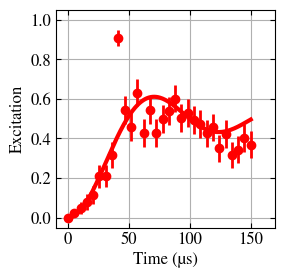

In [3]:
'''Shuttling data with 6.421 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30506

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.07173304743283664
nbar =  22.999999999999996
nalpha =  724.7471000566579


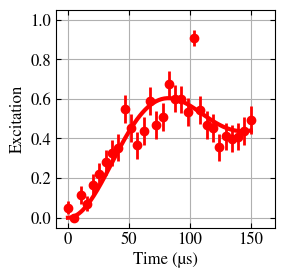

In [4]:
'''Shuttling data with 6.42 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30478

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.14999999999999997
nbar =  0.02818944583853155
nalpha =  749.0610051314102


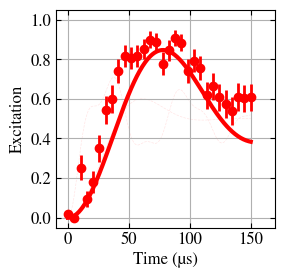

In [5]:
'''Shuttling data with 6.417 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30504

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.14999999999998098
nbar =  0.15379180625848582
nalpha =  740.3253432944576


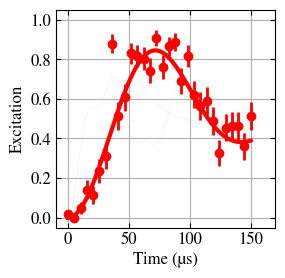

In [6]:
'''Shuttling data with 6.416 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30494

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.13416074620270022
nbar =  5.1430339584446316e-21
nalpha =  742.1114083284708


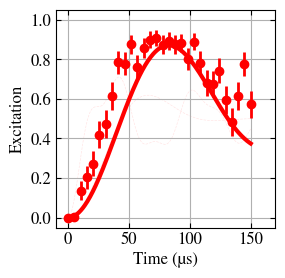

In [7]:
'''Shuttling data with 6.41 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30472

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.1499999999794993
nbar =  0.07582082283177789
nalpha =  767.1560415412894


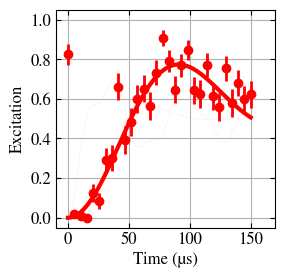

In [8]:
'''Shuttling data with 6.39 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30474

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.14999999999368743
nbar =  0.5070016600974315
nalpha =  733.9938479803631


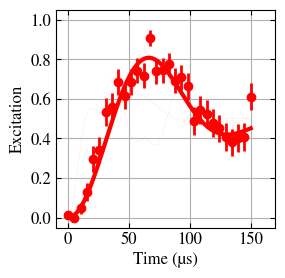

In [9]:
'''Shuttling data with 6.35 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30518

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.14999999999979025
nbar =  7.372294884597874e-19
nalpha =  751.8831048480642


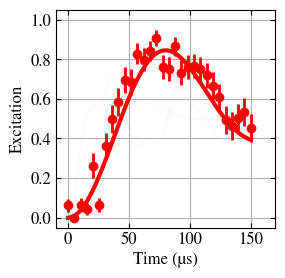

In [10]:
'''Shuttling data with 6.1 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30530

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.14999999999999997
nbar =  0.2854398733354738
nalpha =  738.720794184961


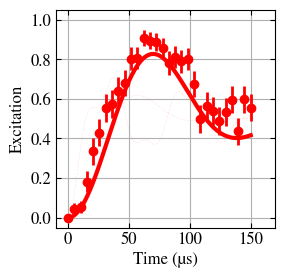

In [11]:
'''Shuttling data with 6.05 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30532

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.11322005149514888
nbar =  7.354477023614233
nalpha =  586.6530614858699


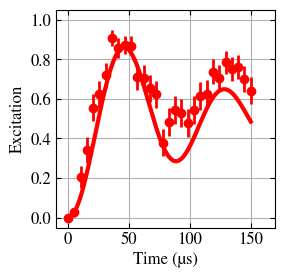

In [12]:
'''Shuttling data with 6.005 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30544

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.0775750175168209
nbar =  11.058954451691157
nalpha =  935.1874305309551


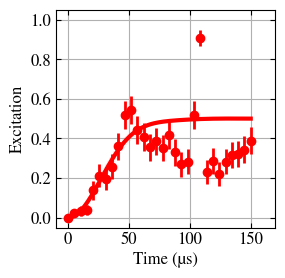

In [13]:
'''Shuttling data with 6.0 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30386

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.12589511880104087
nbar =  11.267631521096451
nalpha =  999.9913014308578


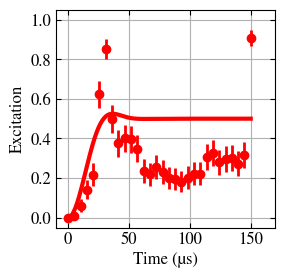

In [14]:
'''Shuttling data with 6.0 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30526

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.1499999907945712
nbar =  22.9999999708056
nalpha =  999.9999849151419


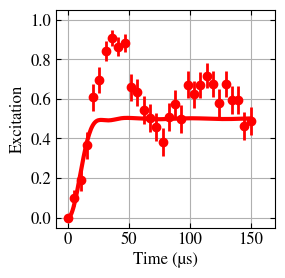

In [15]:
'''Shuttling data with 5.99 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30540

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.08754805215317013
nbar =  22.99999386338841
nalpha =  699.949798705243


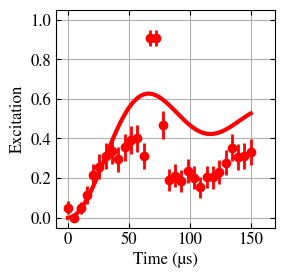

In [16]:
'''Shuttling data with 5.98 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30536

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.038341902000226975
nbar =  9.825170804582354
nalpha =  906.4067208349356


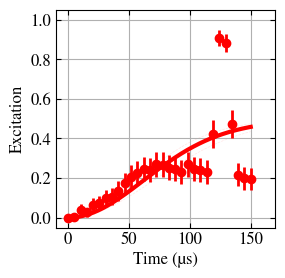

In [17]:
'''Shuttling data with 5.882 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30398

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.14999999999999827
nbar =  0.6225688746108056
nalpha =  737.7952167096755


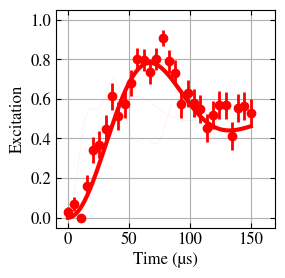

In [18]:
'''Shuttling data with 5.7 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30550

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.12442419823682621
nbar =  9.47359635460168e-12
nalpha =  755.7402920743226


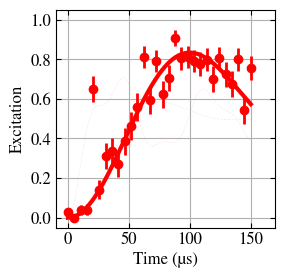

In [19]:
'''Shuttling data with 5.556 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30402

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.0746126372514389
nbar =  22.999999999999996
nalpha =  822.3220184547773


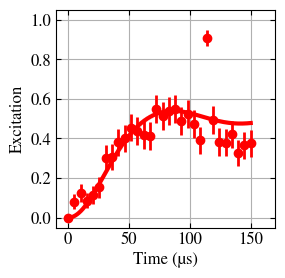

In [20]:
'''Shuttling data with 5.5 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30552

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.1454145387604004
nbar =  8.674641980163997
nalpha =  737.2400660651527


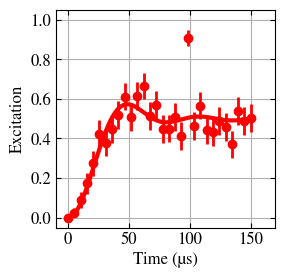

In [21]:
'''Shuttling data with 5.3 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30558

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.04064549040441148
nbar =  8.080416472146668
nalpha =  891.6603294332396


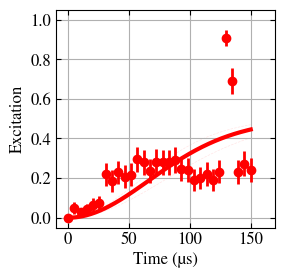

In [22]:
'''Shuttling data with 5.263 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30404

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.035117075195067474
nbar =  22.99999831323634
nalpha =  987.3049487898917


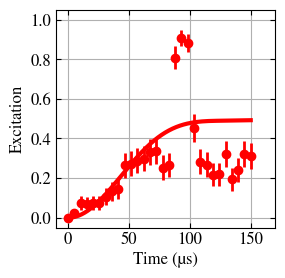

In [23]:
'''Shuttling data with 5.2 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30572

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.14999999999963354
nbar =  1.1488442246042192
nalpha =  717.9055510084083


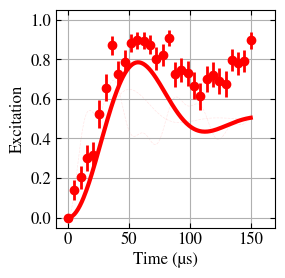

In [24]:
'''Shuttling data with 5.15 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30568

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.04766003857926169
nbar =  7.436746207736064
nalpha =  884.9043988445468


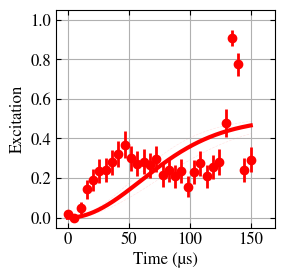

In [25]:
'''Shuttling data with 5.1 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30562

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.13341145538126875
nbar =  5.633477803408506e-17
nalpha =  753.304605539161


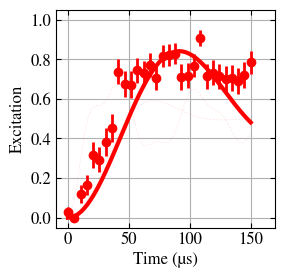

In [26]:
'''Shuttling data with 5.0 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30422

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.1470560901110453
nbar =  2.4624695910665668e-12
nalpha =  763.9590293226294


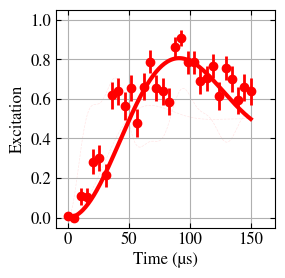

In [27]:
'''Shuttling data with 5.0 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30564

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.11473160447748922
nbar =  14.707794851669794
nalpha =  475.5674600400671


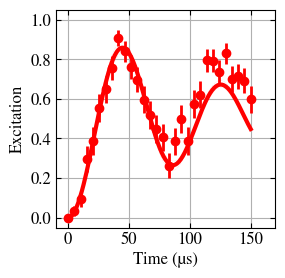

In [28]:
'''Shuttling data with 4.762 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30414

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.14999999999998276
nbar =  2.4843760125781515
nalpha =  649.7636907555018


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/qutip/states.py:416: RuntimeWarning: invalid value encountered in log
  beta = np.log(1.0 / n + 1.0)


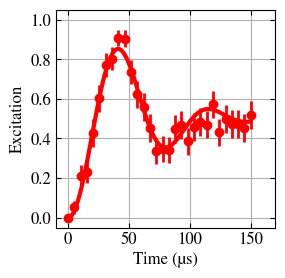

In [29]:
'''Shuttling data with 4.761 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30426

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.11868237130895497
nbar =  22.999999999999996
nalpha =  632.4131998450168


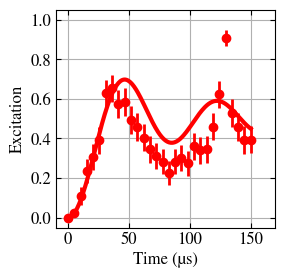

In [30]:
'''Shuttling data with 4.761 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30428

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.11436808010603447
nbar =  11.106137144608711
nalpha =  585.3241948553916


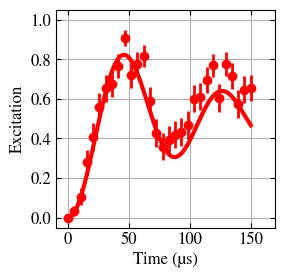

In [31]:
'''Shuttling data with 4.761 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30432

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.14999999997435293
nbar =  2.360714758100145
nalpha =  668.905400951877


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/qutip/states.py:416: RuntimeWarning: invalid value encountered in log
  beta = np.log(1.0 / n + 1.0)


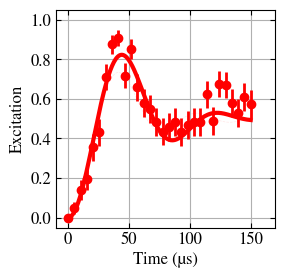

In [32]:
'''Shuttling data with 4.76 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30438

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.12491323328932327
nbar =  6.836360443678284e-11
nalpha =  750.556291869526


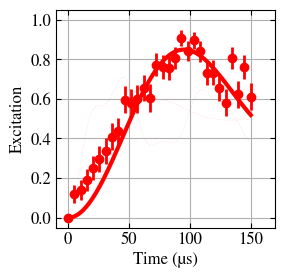

In [33]:
'''Shuttling data with 4.5454 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30448

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.08356373920102884
nbar =  22.999958026142245
nalpha =  947.8929499470395


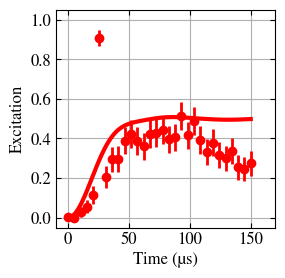

In [34]:
'''Shuttling data with 4.3478 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30456

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.040119837849797835
nbar =  10.765058296204343
nalpha =  911.1572966797227


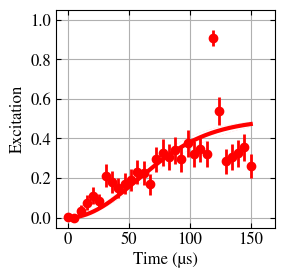

In [35]:
'''Shuttling data with 4.0 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30464

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: overflow encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:201: RuntimeWarning: invalid value encountered in multiply
  w *= mu0 / w.sum()
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:126: RuntimeWarning: invalid value encountered in double_scalars
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:195: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (fm * dy)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513:

Fitted parameters:
rabi =  0.14999999999999997
nbar =  2.8958305919056873
nalpha =  661.826683375426


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/qutip/states.py:416: RuntimeWarning: invalid value encountered in log
  beta = np.log(1.0 / n + 1.0)


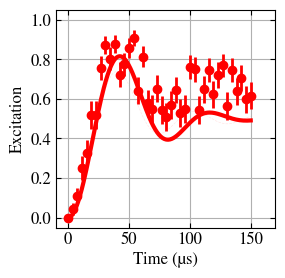

In [36]:
'''Shuttling data with 1.1 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30350

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
'''Shuttling data with 1.1 kHz shuttling speed'''
N_0 = 500

# Wrapper for curve_fit
def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N_0)

n_samples = 50

# Specify the data path and file details
data_path = "/Users/QUBIT/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30350

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = []  # Added 12 to the list
keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

# Initial guesses
# initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
# bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
bounds = ((0.02, 0, 1), (0.15, 23, 1000))
# bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
# Initial guess is the center of the bounds
initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

# Perform the curve fitting
popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
# n_ions = 9
# N = 400
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=N_0)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:513: RuntimeWarning: overflow encountered in multiply
  - (n + alpha)*cephes.eval_genlaguerre(n-1, alpha, x))/x
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/scipy/special/orthogonal.py:194: RuntimeWarning: invalid value encountered in divide
  dy /= np.abs(dy).max()
